# $-u'' + u = f$ with Dirichlet and Neumann conditions, cubic splines

We solve

$$-u''(x) + u(x) = f(x), \quad 0 < x < 1, \qquad u(0) = 1, \quad u'(1) = g,$$

with the exact solution $u(x) = 1 + x + \sin(\pi x)$, so that $f(x) = (\pi^2 + 1)\sin(\pi x) + 1 + x$ and $g = u'(1) = 1 - \pi$.

Multiplying by a test function $v$ with $v(0) = 0$ and integrating by parts gives the boundary term $-u'(1)\,v(1) = -g\,v(1)$. The weak form is: find $u$ with $u(0) = 1$ such that

$$\int_0^1 u' v' \, dx + \int_0^1 u v \, dx = \int_0^1 f v \, dx + g\, v(1)$$

for every test function $v$ that vanishes at $x = 0$. The Dirichlet condition is built into the space, and the Neumann condition is natural: it enters only through the term $g\,v(1)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import D, dx, ds

Cubic splines on 20 equal elements. `bc=("dirichlet", "free")` builds the Dirichlet condition in at the left end and leaves the right end free, for the natural Neumann condition. `left=` gives the Dirichlet value $u(0) = 1$, once, with the space.

In [2]:
grid = np.linspace(0, 1, 21)
V = fd.SplineSpace(grid, 3, bc=("dirichlet", "free"), left=1.0)
u, v = fd.TrialFunction(V), fd.TestFunction(V)

The bilinear form, the right-hand side with the Neumann term `g * v * ds("right")` (the point value $g\,v(1)$), and the solve, which takes the Dirichlet value from the space.

In [3]:
f = (np.pi**2 + 1) * fd.sin(np.pi * fd.x) + 1 + fd.x
g = 1 - np.pi

a = D(u) * D(v) * dx + u * v * dx
L = f * v * dx + g * v * ds("right")

uh = fd.solve(a, L)

Compare with the exact solution: the maximum error, sampled on 401 points, and the $L^2$ error, $\|u_h - u\|_{L^2} = \left(\int_0^1 (u_h - u)^2\,dx\right)^{1/2}$, integrated by quadrature on each element.

max error: 8.501012773720618e-07
L2 error:  3.958296528309124e-07
u'(1) = -2.1415920750854864   exact: -2.141592653589793


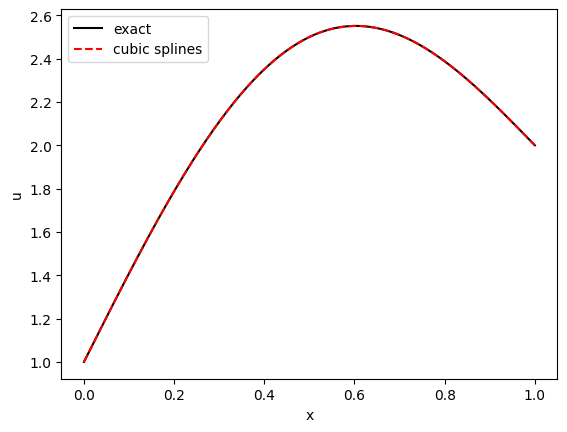

In [4]:
xs = np.linspace(0, 1, 401)
exact = 1 + xs + np.sin(np.pi * xs)
errinf = np.max(np.abs(uh(xs) - exact))
print("max error:", errinf)

uex = 1 + fd.x + fd.sin(np.pi * fd.x)             # the exact solution as an expression in x
errL2 = np.sqrt(fd.form((uh - uex)**2 * dx).assemble())
print("L2 error: ", errL2)
print("u'(1) =", uh(1.0, 1).item(), "  exact:", g)

plt.plot(xs, exact, "k-", label="exact")
plt.plot(xs, uh(xs), "r--", label="cubic splines")
plt.xlabel("x"); plt.ylabel("u"); plt.legend()
plt.show()